# Elastic Weight Consolidation

In [2]:
#Import Libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import copy

device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cpu


In [3]:
# Building DataPipeline
dataset_a = pd.read_csv('../data/spilts/dataset_a.csv')
dataset_b = pd.read_csv('../data/spilts/dataset_b.csv')

Features = ['compound_encoded', 'TyreLife', 'tyre_life_norm',
            'LapNumber', 'lapnumber_norm', 'StintNumber']
Target = 'LapTimeSeconds'

clean_a = dataset_a[Features + [Target]].dropna().reset_index(drop=True)
clean_b = dataset_b[Features + [Target]].dropna().reset_index(drop=True)

scaler = StandardScaler()
X_a = scaler.fit_transform(clean_a[Features].values)
y_a = clean_a[Target].values

X_b = scaler.transform(clean_b[Features].values)
y_b = clean_b[Target].values

X_a_tensor = torch.FloatTensor(X_a)
y_a_tensor = torch.FloatTensor(y_a).reshape(-1, 1)
X_b_tensor = torch.FloatTensor(X_b)
y_b_tensor = torch.FloatTensor(y_b).reshape(-1, 1)

loader_a = DataLoader(TensorDataset(X_a_tensor, y_a_tensor), batch_size=64, shuffle=True)
loader_b = DataLoader(TensorDataset(X_b_tensor, y_b_tensor), batch_size=64, shuffle=True)

print(f'Dataset A: {X_a_tensor.shape}')
print(f'Dataset B: {X_b_tensor.shape}')

Dataset A: torch.Size([2697, 6])
Dataset B: torch.Size([2533, 6])


In [4]:
# Model and Eval 
class LapTimeNet(nn.Module):
    def __init__(self, input_size):
        super(LapTimeNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        return self.network(x)

def evaluate_model(model, X_tensor, y_true):
    model.eval()
    with torch.no_grad():
        predictions = model(X_tensor).numpy().flatten()
    mae = mean_absolute_error(y_true, predictions)
    rmse = np.sqrt(mean_squared_error(y_true, predictions))
    return mae, rmse, predictions

In [5]:
#Baseline Numbers
model = LapTimeNet(input_size=len(Features))
model.load_state_dict(torch.load('../outputs/models/model_after_A.pt', 
                                  map_location=device))
model = model.to(device)

# verify baseline numbers match phase 3
mae_a_baseline, rmse_a_baseline, _ = evaluate_model(model, X_a_tensor, y_a)
mae_b_baseline, rmse_b_baseline, _ = evaluate_model(model, X_b_tensor, y_b)

print(f'Dataset A baseline MAE: {mae_a_baseline:.3f}s')
print(f'Dataset B baseline MAE: {mae_b_baseline:.3f}s')

Dataset A baseline MAE: 5.176s
Dataset B baseline MAE: 5.958s


In [7]:
class EWC:
    def __init__(self, model, dataset_loader):
        self.model = model
        # store the current parameter values after training on Dataset A
        self.params_a = {n: p.clone().detach() 
                        for n, p in model.named_parameters()}
        # compute fisher information for each parameter
        self.fisher = self._compute_fisher(dataset_loader)
        
    def _compute_fisher(self, loader):
        fisher = {n: torch.zeros_like(p) 
                 for n, p in self.model.named_parameters()}
        
        self.model.eval()
        
        for X_batch, y_batch in loader:
            self.model.zero_grad()
            output = self.model(X_batch)
            # use MSE loss gradient to estimate fisher
            loss = nn.MSELoss()(output, y_batch)
            loss.backward()
            
            for n, p in self.model.named_parameters():
                if p.grad is not None:
                    # fisher is the squared gradient
                    fisher[n] += p.grad.data ** 2
        
        # normalise by number of batches
        for n in fisher:
            fisher[n] /= len(loader)
            
        return fisher
    
    def penalty(self, model):
        loss = 0
        for n, p in model.named_parameters():
            # penalise deviation from Dataset A weights
            # weighted by how important each weight was
            loss += (self.fisher[n] * (p - self.params_a[n]) ** 2).sum()
        return loss

In [8]:
#Ewc Train
def train_ewc(model, loader, ewc, lambda_ewc, epochs=50, lr=0.001):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_history = []
    ewc_penalty_history = []
    
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        epoch_penalty = 0
        
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            
            optimizer.zero_grad()
            predictions = model(X_batch)
            
            # task loss on Dataset B
            task_loss = criterion(predictions, y_batch)
            
            # ewc penalty protecting Dataset A knowledge
            ewc_loss = lambda_ewc * ewc.penalty(model)
            
            # total loss
            total_loss = task_loss + ewc_loss
            total_loss.backward()
            optimizer.step()
            
            epoch_loss += task_loss.item()
            epoch_penalty += ewc_loss.item()
        
        avg_loss = epoch_loss / len(loader)
        avg_penalty = epoch_penalty / len(loader)
        loss_history.append(avg_loss)
        ewc_penalty_history.append(avg_penalty)
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} — Task Loss: {avg_loss:.4f} | EWC Penalty: {avg_penalty:.4f}")
    
    return loss_history, ewc_penalty_history

In [9]:
print("Computing Fisher Information on Dataset A...")
ewc = EWC(model, loader_a)

print("\nFisher scores per layer:")
for name, fisher_val in ewc.fisher.items():
    print(f"{name}: mean fisher = {fisher_val.mean().item():.6f}")

Computing Fisher Information on Dataset A...

Fisher scores per layer:
network.0.weight: mean fisher = 4.710906
network.0.bias: mean fisher = 22.200579
network.3.weight: mean fisher = 1.020474
network.3.bias: mean fisher = 1.617726
network.6.weight: mean fisher = 749.826050
network.6.bias: mean fisher = 13.003962


In [10]:
lambda_values = [0.1, 1, 10, 100]
results = {}

for lambda_ewc in lambda_values:
    print(f"\n--- Testing Lambda = {lambda_ewc} ---")
    
    # reload fresh model from phase 3 checkpoint for each lambda
    model_ewc = LapTimeNet(input_size=len(Features))
    model_ewc.load_state_dict(torch.load('../outputs/models/model_after_A.pt',
                                          map_location=device))
    model_ewc = model_ewc.to(device)
    
    # recompute ewc on fresh model
    ewc_fresh = EWC(model_ewc, loader_a)
    
    # train with ewc protection
    loss_history, penalty_history = train_ewc(
        model_ewc, loader_b, ewc_fresh, lambda_ewc, epochs=50
    )
    
    # evaluate on both datasets
    mae_a, rmse_a, _ = evaluate_model(model_ewc, X_a_tensor, y_a)
    mae_b, rmse_b, _ = evaluate_model(model_ewc, X_b_tensor, y_b)
    
    results[lambda_ewc] = {
        'mae_a': mae_a,
        'mae_b': mae_b,
        'rmse_a': rmse_a,
        'rmse_b': rmse_b
    }
    
    print(f"Dataset A MAE: {mae_a:.3f}s | Dataset B MAE: {mae_b:.3f}s")

print("\nDone!")


--- Testing Lambda = 0.1 ---
Epoch 10/50 — Task Loss: 147.7094 | EWC Penalty: 0.4075
Epoch 20/50 — Task Loss: 154.4052 | EWC Penalty: 0.8836
Epoch 30/50 — Task Loss: 148.0395 | EWC Penalty: 1.3976
Epoch 40/50 — Task Loss: 159.3440 | EWC Penalty: 1.8564
Epoch 50/50 — Task Loss: 153.3089 | EWC Penalty: 2.2989
Dataset A MAE: 5.462s | Dataset B MAE: 4.143s

--- Testing Lambda = 1 ---
Epoch 10/50 — Task Loss: 151.6173 | EWC Penalty: 1.5714
Epoch 20/50 — Task Loss: 149.2503 | EWC Penalty: 2.2291
Epoch 30/50 — Task Loss: 148.9460 | EWC Penalty: 2.7342
Epoch 40/50 — Task Loss: 157.9938 | EWC Penalty: 2.8279
Epoch 50/50 — Task Loss: 157.4175 | EWC Penalty: 2.9413
Dataset A MAE: 5.594s | Dataset B MAE: 4.420s

--- Testing Lambda = 10 ---
Epoch 10/50 — Task Loss: 144.6027 | EWC Penalty: 2.8168
Epoch 20/50 — Task Loss: 169.8412 | EWC Penalty: 3.8884
Epoch 30/50 — Task Loss: 151.1177 | EWC Penalty: 3.0762
Epoch 40/50 — Task Loss: 156.9450 | EWC Penalty: 2.9795
Epoch 50/50 — Task Loss: 160.7351 | E

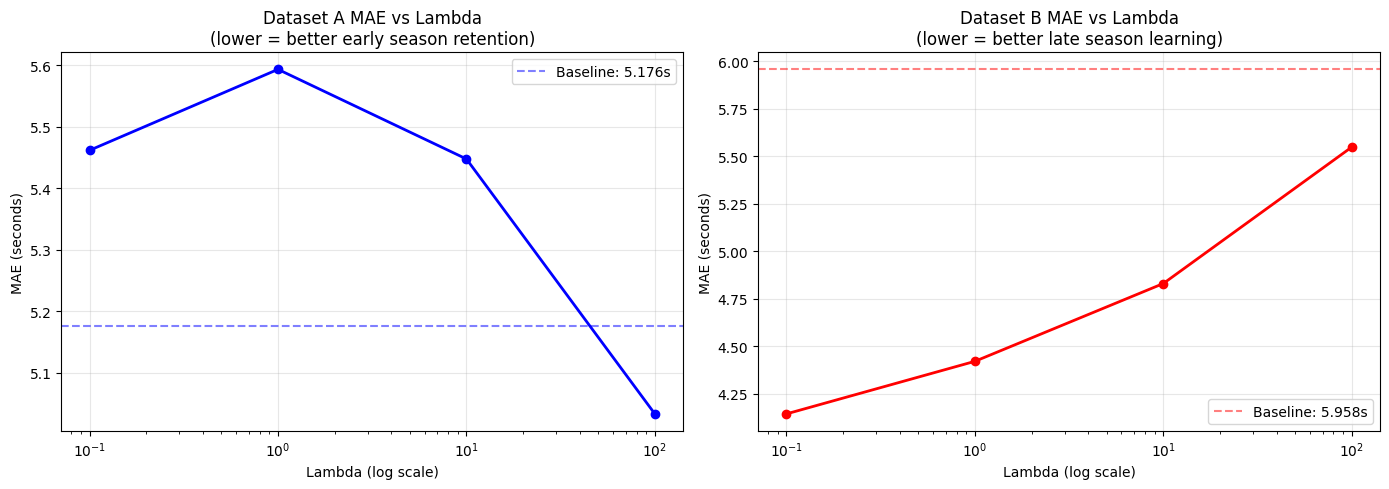

In [11]:
lambdas = list(results.keys())
mae_a_values = [results[l]['mae_a'] for l in lambdas]
mae_b_values = [results[l]['mae_b'] for l in lambdas]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Dataset A protection
axes[0].plot(lambdas, mae_a_values, marker='o', color='blue', linewidth=2)
axes[0].axhline(y=mae_a_baseline, color='blue', linestyle='--', 
                alpha=0.5, label=f'Baseline: {mae_a_baseline:.3f}s')
axes[0].set_xscale('log')
axes[0].set_title('Dataset A MAE vs Lambda\n(lower = better early season retention)')
axes[0].set_xlabel('Lambda (log scale)')
axes[0].set_ylabel('MAE (seconds)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Dataset B learning
axes[1].plot(lambdas, mae_b_values, marker='o', color='red', linewidth=2)
axes[1].axhline(y=mae_b_baseline, color='red', linestyle='--',
                alpha=0.5, label=f'Baseline: {mae_b_baseline:.3f}s')
axes[1].set_xscale('log')
axes[1].set_title('Dataset B MAE vs Lambda\n(lower = better late season learning)')
axes[1].set_xlabel('Lambda (log scale)')
axes[1].set_ylabel('MAE (seconds)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/plots/lambda_tradeoff.png')
plt.show()

In [12]:
print("\n=== FINAL RESULTS SUMMARY ===\n")
print(f"{'Approach':<30} {'Dataset A MAE':>15} {'Dataset B MAE':>15}")
print("-" * 62)
print(f"{'Baseline (A only)':<30} {mae_a_baseline:>14.3f}s {mae_b_baseline:>14.3f}s")

for l in lambda_values:
    label = f'EWC λ={l}'
    print(f"{label:<30} {results[l]['mae_a']:>14.3f}s {results[l]['mae_b']:>14.3f}s")


=== FINAL RESULTS SUMMARY ===

Approach                         Dataset A MAE   Dataset B MAE
--------------------------------------------------------------
Baseline (A only)                       5.176s          5.958s
EWC λ=0.1                               5.462s          4.143s
EWC λ=1                                 5.594s          4.420s
EWC λ=10                                5.448s          4.830s
EWC λ=100                               5.034s          5.548s
